In [2]:
import os
from pathlib import Path
from dotenv import load_dotenv

cwd = Path.cwd()
# Load dotenv into sys PATH
dotenv_file = cwd / "../../../example/.env"
assert dotenv_file.is_file()
load_dotenv(dotenv_file)

True

In [3]:
from py_madaclim.raster_manipulation import MadaclimCollection
from py_madaclim.info import MadaclimLayers
from py_madaclim.raster_manipulation import MadaclimRasters
from pathlib import Path

mada_info = MadaclimLayers()

raster_files = ["madaclim_current.tif", "madaclim_enviro.tif"]
if not all([(cwd / raster_file).exists() for raster_file in raster_files]):
    mada_info.download_data(save_dir=cwd)

mada_info.clim_raster = "./madaclim_current.tif"
mada_info.env_raster = "./madaclim_enviro.tif"


cwd = Path.cwd()
mada_rasters = MadaclimRasters(clim_raster=cwd / "madaclim_current.tif", env_raster=cwd / "madaclim_enviro.tif")

clim_labels =  [label for label in mada_info.get_layers_labels(as_descriptive_labels=True) if "clim" in label]
env_labels = [label for label in mada_info.get_layers_labels(as_descriptive_labels=True) if "env" in label]

In [4]:
import re
# Functions to extract part of the specimen_id for matching

def extract_name(specimen_id):
    # Ensure the input is a string and remove leading/trailing underscores or spaces
    if isinstance(specimen_id, str):
        specimen_id = specimen_id.strip('_ ').strip()
        # Split by either an underscore or space, and take the first part
        split_result = re.split(r'[_\s]', specimen_id)
        return split_result[0] if split_result else specimen_id
    return specimen_id



def extract_id(specimen_id):
    # Use regex to extract the part of the string after the last underscore
    match = re.search(r'_(\w+)$', specimen_id)
    if match:
        return match.group(1)  # Return the ID after the underscore
    return None  # Return None if no match is found




Import coordinates provided by Dr Guyot


In [5]:
import pandas as pd
csv_file = r"../input/position_all_species.csv"
coff_all = pd.read_csv(csv_file)
coff_all.shape

(3783, 3)

In [6]:
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', 1000)
pd.set_option('display.expand_frame_repr', False)  # Disable line-wrapping
pd.set_option('display.max_rows', None)


In [7]:

coff_all = coff_all.rename(columns={
    'name': 'specimen_id',
    'long': 'longitude',
    'lat': 'latitude'
})


coff_all.to_csv(r"../data/dr_guyot_all_for_collection.csv", index=False)
coff_all.head

<bound method NDFrame.head of                     specimen_id   latitude   longitude
0              Coffea_abbayesii -24.366660   46.450000
1              Coffea_abbayesii -24.730000   46.830000
2              Coffea_abbayesii -24.733300   46.833300
3              Coffea_abbayesii -24.666670   46.833330
4              Coffea_abbayesii -24.733333   46.833333
5              Coffea_abbayesii -24.800000   46.850000
6              Coffea_abbayesii -24.760833   46.863333
7              Coffea_abbayesii -24.836667   46.962222
8              Coffea_abbayesii -24.842778   47.136111
9              Coffea_abbayesii -24.835833   47.136667
10             Coffea_abbayesii -24.835216   47.140100
11             Coffea_abbayesii -24.796389   47.166111
12             Coffea_abbayesii -21.382500   47.863889
13             Coffea_abbayesii -21.383333   47.866667
14             Coffea_abbayesii -21.377889   47.867861
15           Coffea_ambanjensis -14.066670   48.283330
16           Coffea_ambanjensis -14

In [8]:
coff_all.shape

(3783, 3)

In [20]:
csv_file = r"../input\no_caffeine_nodes_w_specimen.csv"
nodes_w_caff = pd.read_csv(csv_file)
nodes_w_caff.shape
nodes_w_caff

,Species_name,caffeine_percent
0,C_andrambovatensis_A310,0.000
1,C_abbayesii_A601,0.000
2,C_arenesiana_A403,0.000
3,C_bertrandii_A5,0.000
4,C_dubardii_A969,0.000
5,C_heimii_A516,0.000
6,C_humbertii_RNF785,0.000
7,C_humblotiana_BM19_20,0.000
8,C_millotii_A222,0.000
9,C_perrieri_A12,0.000


In [21]:
# In nodes_w_caff, extract the core species part (e.g., "abbayesii")
nodes_w_caff['species_core'] = nodes_w_caff['Species_name'].str.extract(r'C_([a-z]+)', expand=False)

# In coff_all, extract the species from specimen_id (e.g., "abbayesii" from "Coffea_abbayesii")
coff_all['species_core'] = coff_all['specimen_id'].str.extract(r'Coffea_([a-z]+)', expand=False)


In [22]:
nodes_w_caff

,Species_name,caffeine_percent,species_core
0,C_andrambovatensis_A310,0.000,andrambovatensis
1,C_abbayesii_A601,0.000,abbayesii
2,C_arenesiana_A403,0.000,arenesiana
3,C_bertrandii_A5,0.000,bertrandii
4,C_dubardii_A969,0.000,dubardii
5,C_heimii_A516,0.000,heimii
6,C_humbertii_RNF785,0.000,humbertii
7,C_humblotiana_BM19_20,0.000,humblotiana
8,C_millotii_A222,0.000,millotii
9,C_perrieri_A12,0.000,perrieri


In [23]:
coff_all

,specimen_id,latitude,longitude,species_core
0,Coffea_abbayesii,-24.366660,46.450000,abbayesii
1,Coffea_abbayesii,-24.730000,46.830000,abbayesii
2,Coffea_abbayesii,-24.733300,46.833300,abbayesii
3,Coffea_abbayesii,-24.666670,46.833330,abbayesii
4,Coffea_abbayesii,-24.733333,46.833333,abbayesii
5,Coffea_abbayesii,-24.800000,46.850000,abbayesii
6,Coffea_abbayesii,-24.760833,46.863333,abbayesii
7,Coffea_abbayesii,-24.836667,46.962222,abbayesii
8,Coffea_abbayesii,-24.842778,47.136111,abbayesii
9,Coffea_abbayesii,-24.835833,47.136667,abbayesii


In [24]:
# Keep only rows in coff_all that match a species_core from nodes_w_caff
matched_species = nodes_w_caff['species_core'].unique()
coff_matched = coff_all[coff_all['species_core'].isin(matched_species)].copy()
coff_matched

,specimen_id,latitude,longitude,species_core
0,Coffea_abbayesii,-24.366660,46.450000,abbayesii
1,Coffea_abbayesii,-24.730000,46.830000,abbayesii
2,Coffea_abbayesii,-24.733300,46.833300,abbayesii
3,Coffea_abbayesii,-24.666670,46.833330,abbayesii
4,Coffea_abbayesii,-24.733333,46.833333,abbayesii
5,Coffea_abbayesii,-24.800000,46.850000,abbayesii
6,Coffea_abbayesii,-24.760833,46.863333,abbayesii
7,Coffea_abbayesii,-24.836667,46.962222,abbayesii
8,Coffea_abbayesii,-24.842778,47.136111,abbayesii
9,Coffea_abbayesii,-24.835833,47.136667,abbayesii


In [25]:
coff_model_df = coff_matched.rename(columns={'specimen_id': 'specimen_name'})
coff_model_df['specimen_id'] = coff_model_df['species_core'] + "_" + coff_model_df.index.astype(str)
coff_model_df.drop(columns='species_core', inplace=True)
coff_model_df

,specimen_name,latitude,longitude,specimen_id
0,Coffea_abbayesii,-24.366660,46.450000,abbayesii_0
1,Coffea_abbayesii,-24.730000,46.830000,abbayesii_1
2,Coffea_abbayesii,-24.733300,46.833300,abbayesii_2
3,Coffea_abbayesii,-24.666670,46.833330,abbayesii_3
4,Coffea_abbayesii,-24.733333,46.833333,abbayesii_4
5,Coffea_abbayesii,-24.800000,46.850000,abbayesii_5
6,Coffea_abbayesii,-24.760833,46.863333,abbayesii_6
7,Coffea_abbayesii,-24.836667,46.962222,abbayesii_7
8,Coffea_abbayesii,-24.842778,47.136111,abbayesii_8
9,Coffea_abbayesii,-24.835833,47.136667,abbayesii_9


In [ ]:
# nodes_w_caff.drop(columns='species_core', inplace=True)
# coff_all.drop(columns='species_core', inplace=True)


In [26]:
def filter_madaclim_bounds(df, lon_col='longitude', lat_col='latitude'):
    """
    Filter rows that fall within the geographic extent of the Madaclim raster dataset.

    Madaclim bounds:
        Longitude: 42.99 to 50.98
        Latitude: -25.62 to -11.95 (optional but can include if needed)
    """
    lon_min, lon_max = 42.99, 50.98
    lat_min, lat_max = -25.62, -11.95  # Approx. Madagascar's extent

    filtered = df[
        (df[lon_col] >= lon_min) & (df[lon_col] <= lon_max) &
        (df[lat_col] >= lat_min) & (df[lat_col] <= lat_max)
    ].copy()

    excluded = df[~df.index.isin(filtered.index)].copy()
    return filtered, excluded


In [27]:
coff_in_bounds, coff_out_of_bounds = filter_madaclim_bounds(coff_model_df)
print(f"Included for modeling: {coff_in_bounds.shape[0]} rows")
print(f"Excluded due to out-of-bounds: {coff_out_of_bounds.shape[0]} rows")
print("Species excluded:")
print(coff_out_of_bounds['specimen_id'].unique())


Included for modeling: 468 rows
Excluded due to out-of-bounds: 101 rows
Species excluded:
['mauritiana_2371' 'mauritiana_2372' 'mauritiana_2373' 'mauritiana_2374'
 'mauritiana_2375' 'mauritiana_2376' 'mauritiana_2377' 'mauritiana_2378'
 'mauritiana_2379' 'mauritiana_2380' 'mauritiana_2381' 'mauritiana_2382'
 'mauritiana_2383' 'mauritiana_2384' 'mauritiana_2385' 'mauritiana_2386'
 'mauritiana_2387' 'mauritiana_2388' 'mauritiana_2389' 'mauritiana_2390'
 'mauritiana_2391' 'mauritiana_2392' 'mauritiana_2393' 'mauritiana_2394'
 'mauritiana_2395' 'mauritiana_2396' 'mauritiana_2397' 'mauritiana_2398'
 'mauritiana_2399' 'mauritiana_2400' 'mauritiana_2401' 'mauritiana_2402'
 'mauritiana_2403' 'mauritiana_2404' 'mauritiana_2405' 'mauritiana_2406'
 'mauritiana_2407' 'mauritiana_2408' 'mauritiana_2409' 'mauritiana_2410'
 'mauritiana_2411' 'mauritiana_2412' 'mauritiana_2413' 'mauritiana_2414'
 'mauritiana_2415' 'mauritiana_2416' 'mauritiana_2417' 'mauritiana_2418'
 'mauritiana_2419' 'mauritiana_242

In [28]:
print(coff_in_bounds.shape)
print(coff_in_bounds['specimen_id'].unique())


(468, 4)
['abbayesii_0' 'abbayesii_1' 'abbayesii_2' 'abbayesii_3' 'abbayesii_4'
 'abbayesii_5' 'abbayesii_6' 'abbayesii_7' 'abbayesii_8' 'abbayesii_9'
 'abbayesii_10' 'abbayesii_11' 'abbayesii_12' 'abbayesii_13'
 'abbayesii_14' 'andrambovatensis_35' 'andrambovatensis_36'
 'andrambovatensis_37' 'arenesiana_60' 'arenesiana_61' 'arenesiana_62'
 'arenesiana_63' 'arenesiana_64' 'arenesiana_65' 'arenesiana_66'
 'bertrandii_90' 'bertrandii_91' 'bertrandii_92' 'bertrandii_93'
 'bertrandii_94' 'bertrandii_95' 'bertrandii_96' 'bertrandii_97'
 'bertrandii_98' 'dubardii_974' 'dubardii_975' 'dubardii_976'
 'dubardii_977' 'dubardii_978' 'dubardii_979' 'dubardii_980'
 'dubardii_981' 'dubardii_982' 'dubardii_983' 'dubardii_984'
 'dubardii_985' 'dubardii_986' 'dubardii_987' 'dubardii_988'
 'dubardii_989' 'dubardii_990' 'dubardii_991' 'dubardii_992'
 'dubardii_993' 'dubardii_994' 'dubardii_995' 'dubardii_996'
 'dubardii_997' 'dubardii_998' 'dubardii_999' 'dubardii_1000'
 'dubardii_1001' 'dubardii_1002' 

Using data specimens with geolocation coordinates provided by Dr Guyot, a collection will be created for specimens $\textcolor{yellow}{having\ available\ caffeine\ content}$ (including species with confirmed caffeine content of 0)


In [29]:
from py_madaclim.raster_manipulation import MadaclimCollection
coll_all = MadaclimCollection.populate_from_df(coff_in_bounds)
coll_all_clim = MadaclimCollection.populate_from_df(coff_in_bounds)
coll_all_env = MadaclimCollection.populate_from_df(coff_in_bounds)
coll_all.gdf

Warning! No source_crs column in the df. Using the default value of EPSG:4326...
Creating MadaclimPoint(specimen_id=abbayesii_0...)
Creating MadaclimPoint(specimen_id=abbayesii_1...)
Creating MadaclimPoint(specimen_id=abbayesii_2...)
Creating MadaclimPoint(specimen_id=abbayesii_3...)
Creating MadaclimPoint(specimen_id=abbayesii_4...)
Creating MadaclimPoint(specimen_id=abbayesii_5...)
Creating MadaclimPoint(specimen_id=abbayesii_6...)
Creating MadaclimPoint(specimen_id=abbayesii_7...)
Creating MadaclimPoint(specimen_id=abbayesii_8...)
Creating MadaclimPoint(specimen_id=abbayesii_9...)
Creating MadaclimPoint(specimen_id=abbayesii_10...)
Creating MadaclimPoint(specimen_id=abbayesii_11...)
Creating MadaclimPoint(specimen_id=abbayesii_12...)
Creating MadaclimPoint(specimen_id=abbayesii_13...)
Creating MadaclimPoint(specimen_id=abbayesii_14...)
Creating MadaclimPoint(specimen_id=andrambovatensis_35...)
Creating MadaclimPoint(specimen_id=andrambovatensis_36...)
Creating MadaclimPoint(specimen

,specimen_id,source_crs,longitude,latitude,mada_geom_point,sampled_layers,nodata_layers,is_categorical_encoded,specimen_name
0,abbayesii_0,4326,46.450000,-24.366660,POINT (647070.620 7304410.221),None,None,False,Coffea_abbayesii
1,abbayesii_1,4326,46.830000,-24.730000,POINT (685086.872 7263711.611),None,None,False,Coffea_abbayesii
2,abbayesii_2,4326,46.833300,-24.733300,POINT (685415.815 7263341.631),None,None,False,Coffea_abbayesii
3,abbayesii_3,4326,46.833330,-24.666670,POINT (685517.561 7270721.614),None,None,False,Coffea_abbayesii
4,abbayesii_4,4326,46.833333,-24.733333,POINT (685419.104 7263337.931),None,None,False,Coffea_abbayesii
5,abbayesii_5,4326,46.850000,-24.800000,POINT (687005.231 7255931.022),None,None,False,Coffea_abbayesii
6,abbayesii_6,4326,46.863333,-24.760833,POINT (688412.448 7260250.969),None,None,False,Coffea_abbayesii
7,abbayesii_7,4326,46.962222,-24.836667,POINT (698293.473 7251711.089),None,None,False,Coffea_abbayesii
8,abbayesii_8,4326,47.136111,-24.842778,POINT (715860.409 7250769.964),None,None,False,Coffea_abbayesii
9,abbayesii_9,4326,47.136667,-24.835833,POINT (715928.669 7251538.425),None,None,False,Coffea_abbayesii


In [30]:
from py_madaclim.info import MadaclimLayers
mada_info = MadaclimLayers()
mada_info.all_layers

,geoclim_type,layer_number,layer_name,layer_description,is_categorical,units
0,clim,1,tmin1,Monthly minimum temperature - January,False,°C x 10
1,clim,2,tmin2,Monthly minimum temperature - February,False,°C x 10
2,clim,3,tmin3,Monthly minimum temperature - March,False,°C x 10
3,clim,4,tmin4,Monthly minimum temperature - April,False,°C x 10
4,clim,5,tmin5,Monthly minimum temperature - May,False,°C x 10
5,clim,6,tmin6,Monthly minimum temperature - June,False,°C x 10
6,clim,7,tmin7,Monthly minimum temperature - July,False,°C x 10
7,clim,8,tmin8,Monthly minimum temperature - August,False,°C x 10
8,clim,9,tmin9,Monthly minimum temperature - September,False,°C x 10
9,clim,10,tmin10,Monthly minimum temperature - October,False,°C x 10


In [59]:
raster_files = ["madaclim_current.tif", "madaclim_enviro.tif"]
if not all([(cwd / raster_file).exists() for raster_file in raster_files]):
    mada_info.download_data(save_dir=cwd)


In [31]:

mada_info.clim_raster = "./madaclim_current.tif"
mada_info.env_raster = "./madaclim_enviro.tif"
print(mada_info)    # Now the 'get_bandnums_from_layers' is visible

MadaclimLayers(
	all_layers = DataFrame(79 rows x 6 columns)
	categorical_layers = DataFrame(Layers 75, 76, 77, 78 with a total of 79 categories
	clim_raster = madaclim_current.tif
	clim_crs = EPSG:32738
	env_raster = madaclim_enviro.tif
	env_crs = EPSG:32738
	public methods -> download_data, fetch_specific_layers, get_bandnums_from_layers
			 get_categorical_combinations, get_layers_labels, select_geoclim_type_layers
)


In [32]:
from py_madaclim.raster_manipulation import MadaclimRasters
from pathlib import Path
cwd = Path.cwd()
mada_rasters = MadaclimRasters(clim_raster=cwd / "madaclim_current.tif", env_raster=cwd / "madaclim_enviro.tif")
print(mada_rasters)

MadaclimRasters(
	clim_raster = madaclim_current.tif,
	clim_crs = EPSG:32738,
	clim_nodata_val = -32768.0
	env_raster = madaclim_enviro.tif,
	env_crs = EPSG:32738,
	env_nodata_val = -32768.0
)


In [33]:
clim_labels =  [label for label in mada_info.get_layers_labels(as_descriptive_labels=True) if "clim" in label]
env_labels = [label for label in mada_info.get_layers_labels(as_descriptive_labels=True) if "env" in label]

print("clim_labels", len(clim_labels),clim_labels)
print("env_labels",len(env_labels),env_labels)



clim_labels 70 ['clim_1_tmin1_Monthly minimum temperature - January (°C x 10)', 'clim_2_tmin2_Monthly minimum temperature - February (°C x 10)', 'clim_3_tmin3_Monthly minimum temperature - March (°C x 10)', 'clim_4_tmin4_Monthly minimum temperature - April (°C x 10)', 'clim_5_tmin5_Monthly minimum temperature - May (°C x 10)', 'clim_6_tmin6_Monthly minimum temperature - June (°C x 10)', 'clim_7_tmin7_Monthly minimum temperature - July (°C x 10)', 'clim_8_tmin8_Monthly minimum temperature - August (°C x 10)', 'clim_9_tmin9_Monthly minimum temperature - September (°C x 10)', 'clim_10_tmin10_Monthly minimum temperature - October (°C x 10)', 'clim_11_tmin11_Monthly minimum temperature - November (°C x 10)', 'clim_12_tmin12_Monthly minimum temperature - December (°C x 10)', 'clim_13_tmax1_Monthly maximum temperature - January (°C x 10)', 'clim_14_tmax2_Monthly maximum temperature - February (°C x 10)', 'clim_15_tmax3_Monthly maximum temperature - March (°C x 10)', 'clim_16_tmax4_Monthly max

In [34]:


coll_all.sample_from_rasters(
    clim_raster=mada_rasters.clim_raster,
    env_raster=mada_rasters.env_raster,
    layer_info = True
)


######################################## Extracting data for: abbayesii_0 ########################################

Sampling 70 layer(s) from madaclim_current.tif (geoclim_type=clim)...


Extracting layer 70: Number of dry months in the year:  100%|██████████| layer 70/70 [Time remaining: 00:00]                                              



Sampling 9 layer(s) from madaclim_enviro.tif (geoclim_type=env)...


Extracting layer 79: Percentage of forest cover in 1 km by 1 km grid cells:  100%|██████████| layer 9/9 [Time remaining: 00:00]   



Finished raster sampling operation in 0.24 seconds.


######################################## Extracting data for: abbayesii_1 ########################################

Sampling 70 layer(s) from madaclim_current.tif (geoclim_type=clim)...


...


Finished raster sampling operation in 0.20 seconds.


######################################## Extracting data for: vianneyi_3734 ########################################

Sampling 70 layer(s) from madaclim_current.tif (geoclim_type=clim)...


Extracting layer 70: Number of dry months in the year:  100%|██████████| layer 70/70 [Time remaining: 00:00]                                              



Sampling 9 layer(s) from madaclim_enviro.tif (geoclim_type=env)...


Extracting layer 79: Percentage of forest cover in 1 km by 1 km grid cells:  100%|██████████| layer 9/9 [Time remaining: 00:00]   



Finished raster sampling operation in 0.19 seconds.



In [ ]:
# coll_all_clim.sample_from_rasters(
#     clim_raster=mada_rasters.clim_raster,
#     env_raster=mada_rasters.env_raster,
#     layers_to_sample = clim_labels,
#     layer_info = True
# )


In [ ]:
# coll_all_env.sample_from_rasters(
#     clim_raster=mada_rasters.clim_raster,
#     env_raster=mada_rasters.env_raster,
#     layers_to_sample = env_labels,
#     layer_info = True
# )


In [35]:
coll_all.gdf.to_csv(r'../data/coll_all.csv', index=False)


In [ ]:
# coll_all_clim.gdf.to_csv(r'../data/coll_all_clim.csv', index=False)
# coll_all_env.gdf.to_csv(r'../data/coll_all_env.csv', index=False)


Add Raster layer information to the collection

That will be put into the `coll_caff_node.csv` file that will be used in the next steps

In [36]:
categ_layers = mada_info.get_categorical_combinations(as_descriptive_keys=True)
print(list(categ_layers.keys())[0])

env_75_geo_Rock types (categ_vals: 1, 2, 4, 5, 6, 7, 9, 10, 11, 12, 13)


In [ ]:
df = coll_all.gdf[["specimen_id"] + list(categ_layers.keys())]
df.to_csv("../data/coll_all_categ_nonbin.csv")

In [91]:
df.shape

(468, 5)

In [37]:
coll_all.binary_encode_categorical()
coll_all.gdf.to_csv(r'../data/coll_all_bin.csv', index=False)

In [38]:
coll_all.gdf.shape

(468, 167)

In [39]:

unique_values = coll_all.gdf['specimen_id'].unique()

# Print or work with the unique values
print(unique_values)


['abbayesii_0' 'abbayesii_1' 'abbayesii_2' 'abbayesii_3' 'abbayesii_4'
 'abbayesii_5' 'abbayesii_6' 'abbayesii_7' 'abbayesii_8' 'abbayesii_9'
 'abbayesii_10' 'abbayesii_11' 'abbayesii_12' 'abbayesii_13'
 'abbayesii_14' 'andrambovatensis_35' 'andrambovatensis_36'
 'andrambovatensis_37' 'arenesiana_60' 'arenesiana_61' 'arenesiana_62'
 'arenesiana_63' 'arenesiana_64' 'arenesiana_65' 'arenesiana_66'
 'bertrandii_90' 'bertrandii_91' 'bertrandii_92' 'bertrandii_93'
 'bertrandii_94' 'bertrandii_95' 'bertrandii_96' 'bertrandii_97'
 'bertrandii_98' 'dubardii_974' 'dubardii_975' 'dubardii_976'
 'dubardii_977' 'dubardii_978' 'dubardii_979' 'dubardii_980'
 'dubardii_981' 'dubardii_982' 'dubardii_983' 'dubardii_984'
 'dubardii_985' 'dubardii_986' 'dubardii_987' 'dubardii_988'
 'dubardii_989' 'dubardii_990' 'dubardii_991' 'dubardii_992'
 'dubardii_993' 'dubardii_994' 'dubardii_995' 'dubardii_996'
 'dubardii_997' 'dubardii_998' 'dubardii_999' 'dubardii_1000'
 'dubardii_1001' 'dubardii_1002' 'dubardii

#MadaclimCollection points must have unique specimen_id

Creation of a Collection per species for visualisation - example with abbayesii

In [77]:
def extract_rows_containing_word(df, word):
    filtered_df = df[df.apply(lambda row: row.astype(str).str.contains(word, case=False).any(), axis=1)]
    return filtered_df

### Sample from rasters

Just like the `MadaclimPoint` class, use the `sample_from_rasters` method to get data based on the collection's specimens.

In [29]:
from py_madaclim.info import MadaclimLayers
mada_info = MadaclimLayers()

In [31]:
print(mada_info.all_layers.shape)
mada_info.all_layers

(79, 6)


,geoclim_type,layer_number,layer_name,layer_description,is_categorical,units
0,clim,1,tmin1,Monthly minimum temperature - January,False,°C x 10
1,clim,2,tmin2,Monthly minimum temperature - February,False,°C x 10
2,clim,3,tmin3,Monthly minimum temperature - March,False,°C x 10
3,clim,4,tmin4,Monthly minimum temperature - April,False,°C x 10
4,clim,5,tmin5,Monthly minimum temperature - May,False,°C x 10
...,...,...,...,...,...,...
74,env,75,geo,Rock types,True,"[1=Alluvial_&_Lake_deposits, 2=Unconsolidated_..."
75,env,76,soi,Soil types,True,"[1=Bare_Rocks, 2=Raw_Lithic_Mineral_Soils, 3=P..."
76,env,77,veg,Vegetation types,True,"[1=VegCat_01, 2=VegCat_02, 3=VegCat_03, 4=VegC..."
77,env,78,wat,Watersheds,True,"[1=CoE_N-Bemarivo, 2=CoE_S-Bemarivo_N-Mangoro,..."


In [32]:
raster_files = ["madaclim_current.tif", "madaclim_enviro.tif"]
if not all([(cwd / raster_file).exists() for raster_file in raster_files]):
    mada_info.download_data(save_dir=cwd)



####   Trying get request to Madaclim website...   ####
madaclim_current.tif is 21.8 MB
Server response OK from madaclim.cirad.fr, starting to download madaclim_current.tif
Progress for madaclim_current.tif : 100.00 % completed of 21.8 MB downloaded [ average speed of  2.8 MB/s ]
Done downloading madaclim_current.tif in 7.67 seconds !

####   Trying get request to Madaclim website...   ####
madaclim_enviro.tif is 5.5 MB
Server response OK from madaclim.cirad.fr, starting to download madaclim_enviro.tif
Progress for madaclim_enviro.tif : 100.00 % completed of 5.5 MB downloaded [ average speed of  2.1 MB/s ]
Done downloading madaclim_enviro.tif in 2.70 seconds !


In [33]:

mada_info.clim_raster = "./madaclim_current.tif"
mada_info.env_raster = "./madaclim_enviro.tif"
print(mada_info)    # Now the 'get_bandnums_from_layers' is visible

MadaclimLayers(
	all_layers = DataFrame(79 rows x 6 columns)
	categorical_layers = DataFrame(Layers 75, 76, 77, 78 with a total of 79 categories
	clim_raster = madaclim_current.tif
	clim_crs = EPSG:32738
	env_raster = madaclim_enviro.tif
	env_crs = EPSG:32738
	public methods -> download_data, fetch_specific_layers, get_bandnums_from_layers
			 get_categorical_combinations, get_layers_labels, select_geoclim_type_layers
)


In [34]:
from py_madaclim.raster_manipulation import MadaclimRasters
from pathlib import Path
cwd = Path.cwd()
mada_rasters = MadaclimRasters(clim_raster=cwd / "madaclim_current.tif", env_raster=cwd / "madaclim_enviro.tif")
print(mada_rasters)

MadaclimRasters(
	clim_raster = madaclim_current.tif,
	clim_crs = EPSG:32738,
	clim_nodata_val = -32768.0
	env_raster = madaclim_enviro.tif,
	env_crs = EPSG:32738,
	env_nodata_val = -32768.0
)


In [81]:

abbayesii_df = extract_rows_containing_word(coff_in_bounds, "abbayesii")
coll_abbayesii = MadaclimCollection.populate_from_df(abbayesii_df)
coll_abbayesii.sample_from_rasters(
    clim_raster=mada_rasters.clim_raster,
    env_raster=mada_rasters.env_raster
)

Warning! No source_crs column in the df. Using the default value of EPSG:4326...
Creating MadaclimPoint(specimen_id=abbayesii_0...)
Creating MadaclimPoint(specimen_id=abbayesii_1...)
Creating MadaclimPoint(specimen_id=abbayesii_2...)
Creating MadaclimPoint(specimen_id=abbayesii_3...)
Creating MadaclimPoint(specimen_id=abbayesii_4...)
Creating MadaclimPoint(specimen_id=abbayesii_5...)
Creating MadaclimPoint(specimen_id=abbayesii_6...)
Creating MadaclimPoint(specimen_id=abbayesii_7...)
Creating MadaclimPoint(specimen_id=abbayesii_8...)
Creating MadaclimPoint(specimen_id=abbayesii_9...)
Creating MadaclimPoint(specimen_id=abbayesii_10...)
Creating MadaclimPoint(specimen_id=abbayesii_11...)
Creating MadaclimPoint(specimen_id=abbayesii_12...)
Creating MadaclimPoint(specimen_id=abbayesii_13...)
Creating MadaclimPoint(specimen_id=abbayesii_14...)
Created new MadaclimCollection with 15 samples.

######################################## Extracting data for: abbayesii_0 ##########################

Extracting layer 70: Number of dry months in the year:  100%|██████████| layer 70/70 [Time remaining: 00:00]                                              



Sampling 9 layer(s) from madaclim_enviro.tif (geoclim_type=env)...


Extracting layer 79: Percentage of forest cover in 1 km by 1 km grid cells:  100%|██████████| layer 9/9 [Time remaining: 00:00]   



Finished raster sampling operation in 0.20 seconds.


######################################## Extracting data for: abbayesii_1 ########################################

Sampling 70 layer(s) from madaclim_current.tif (geoclim_type=clim)...


...


Finished raster sampling operation in 0.20 seconds.


######################################## Extracting data for: abbayesii_14 ########################################

Sampling 70 layer(s) from madaclim_current.tif (geoclim_type=clim)...


Extracting layer 70: Number of dry months in the year:  100%|██████████| layer 70/70 [Time remaining: 00:00]                                              



Sampling 9 layer(s) from madaclim_enviro.tif (geoclim_type=env)...


Extracting layer 79: Percentage of forest cover in 1 km by 1 km grid cells:  100%|██████████| layer 9/9 [Time remaining: 00:00]   


Finished raster sampling operation in 0.19 seconds.



In [71]:
bioclim_labels = [label for label in mada_info.get_layers_labels(as_descriptive_labels=True) if "bio" in label]

In [82]:
# From the collection's objects
print(list(coll_abbayesii.sampled_layers.keys()))
for specimen_id in coll_abbayesii.sampled_layers:
    print(f"\nSampled layer values for {specimen_id}")
    for layer, value in coll_abbayesii.sampled_layers[specimen_id].items():
        if layer in bioclim_labels[0]:    #print only first bioclim layer
            print(f"{layer} => {value}")    
    

['abbayesii_0', 'abbayesii_1', 'abbayesii_2', 'abbayesii_3', 'abbayesii_4', 'abbayesii_5', 'abbayesii_6', 'abbayesii_7', 'abbayesii_8', 'abbayesii_9', 'abbayesii_10', 'abbayesii_11', 'abbayesii_12', 'abbayesii_13', 'abbayesii_14']

Sampled layer values for abbayesii_0

Sampled layer values for abbayesii_1

Sampled layer values for abbayesii_2

Sampled layer values for abbayesii_3

Sampled layer values for abbayesii_4

Sampled layer values for abbayesii_5

Sampled layer values for abbayesii_6

Sampled layer values for abbayesii_7

Sampled layer values for abbayesii_8

Sampled layer values for abbayesii_9

Sampled layer values for abbayesii_10

Sampled layer values for abbayesii_11

Sampled layer values for abbayesii_12

Sampled layer values for abbayesii_13

Sampled layer values for abbayesii_14


In [72]:
# Or from the geodataframe attribute
coll_all.gdf[["specimen_id"] + bioclim_labels[:1]]

,specimen_id,clim_37_bio1_Annual mean temperature (degrees)
0,abbayesii_0,224.0
1,abbayesii_1,198.0
2,abbayesii_2,198.0
3,abbayesii_3,228.0
4,abbayesii_4,198.0
...,...,...
463,vatovavyensis_3729,229.0
464,vatovavyensis_3730,221.0
465,vianneyi_3732,225.0
466,vianneyi_3733,229.0


exploring categorical data

In [73]:
categ_layers = mada_info.get_categorical_combinations(as_descriptive_keys=True)
print(list(categ_layers.keys())[0])

env_75_geo_Rock types (categ_vals: 1, 2, 4, 5, 6, 7, 9, 10, 11, 12, 13)


In [88]:
# No encoding
df = coll_all.gdf[["specimen_id"] + list(categ_layers.keys())]
df.to_csv("../data/coll_all_categ_nonbin.csv")

In [55]:
# Encoding categorical layers

# coll_heimii.binary_encode_categorical()
# print(coll_heimii.is_categorical_encoded)
# print(f"Shape of geodataframe post one-hot-encoding: {coll_heimii.gdf.shape}")

True
Shape of geodataframe post one-hot-encoding: (8, 168)


Default visualization for `MadaclimCollection` shows all the points on the specific raster map on the left and the actual values for each point on the right

c:\Users\adm1\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\adm1\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


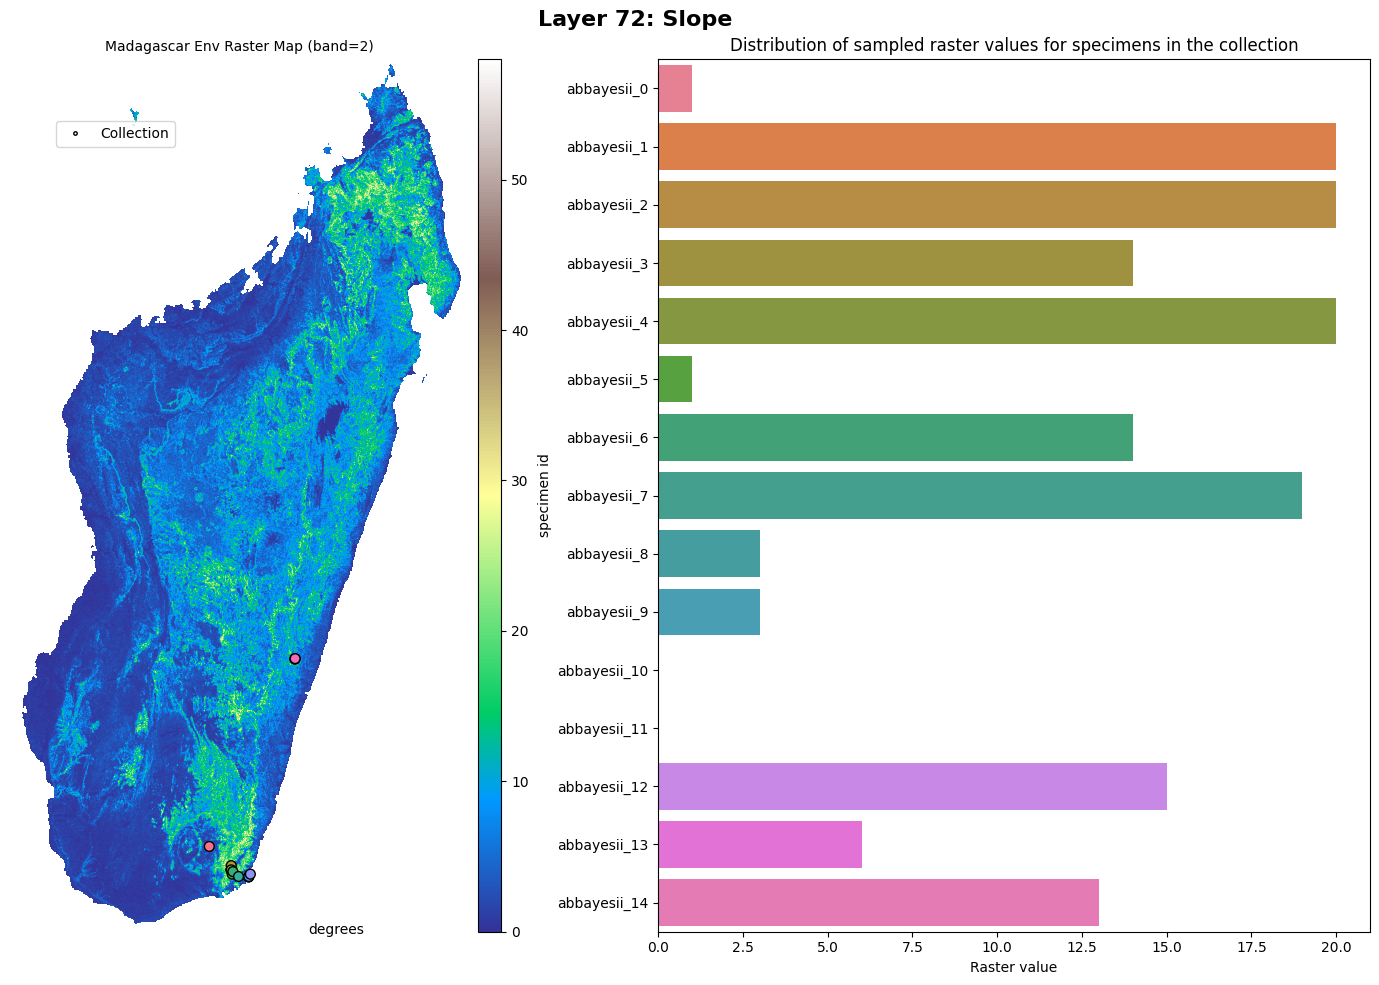

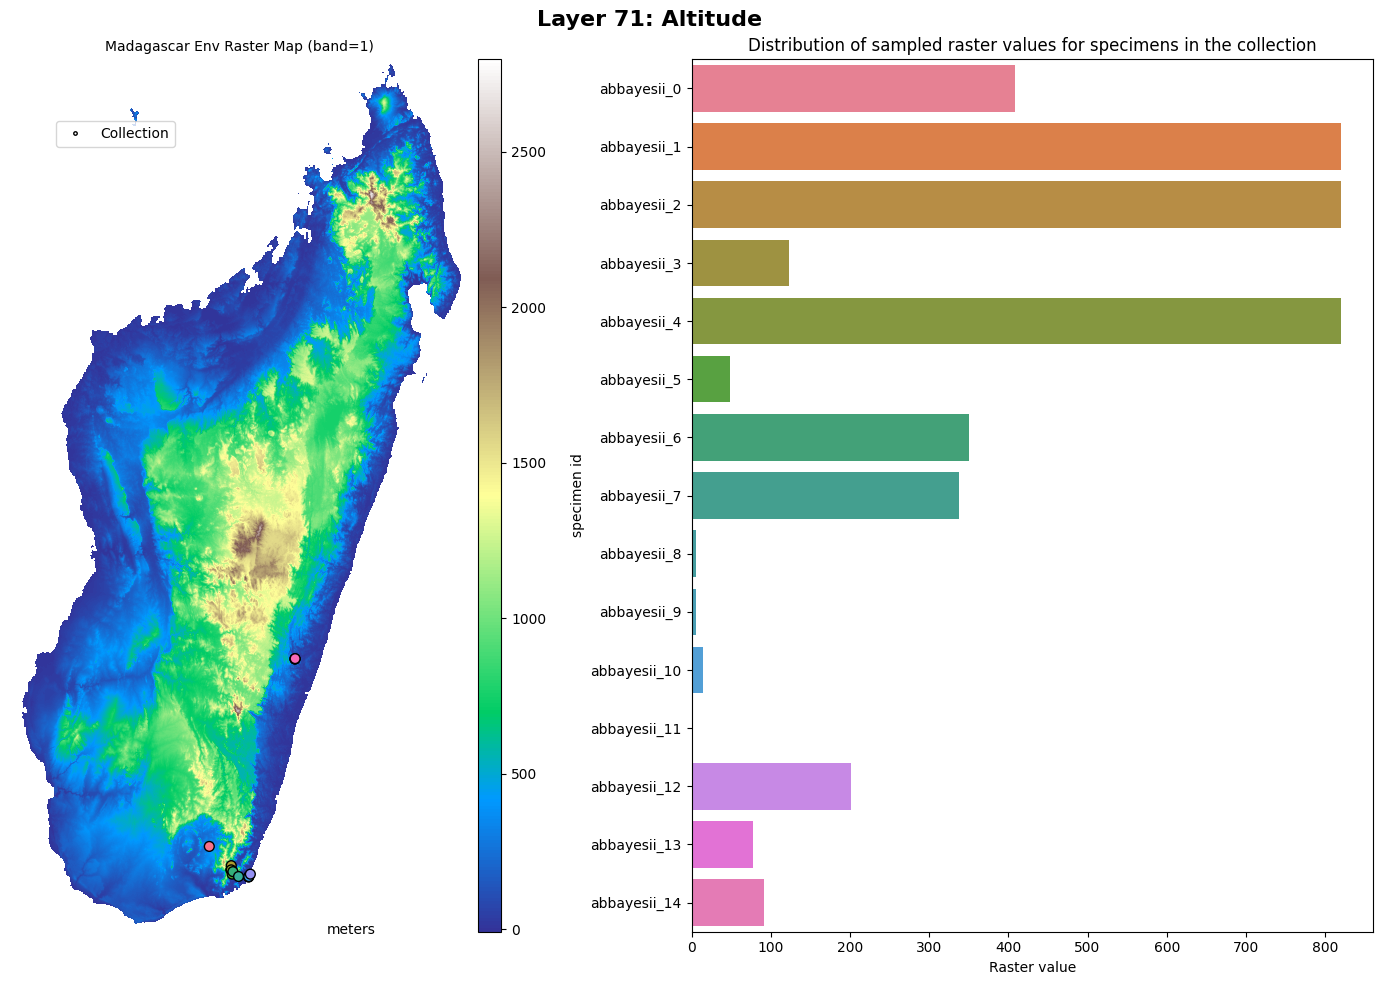

In [83]:
# Base visualization for continuous layers
def view_cont_layers(coll, layer_nb):
    coll_abbayesii.plot_on_layer(layer=layer_nb, 
        imshow_cmap="terrain", 
        histplot_binwidth=100, histplot_stat="count", 
        subplots_figsize=(15, 10))

view_cont_layers(coll_abbayesii, "layer_72")

coll_abbayesii.plot_on_layer(layer="layer_71", 
    imshow_cmap="terrain", 
    histplot_binwidth=100, histplot_stat="count", 
    subplots_figsize=(15, 10))





c:\Users\adm1\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


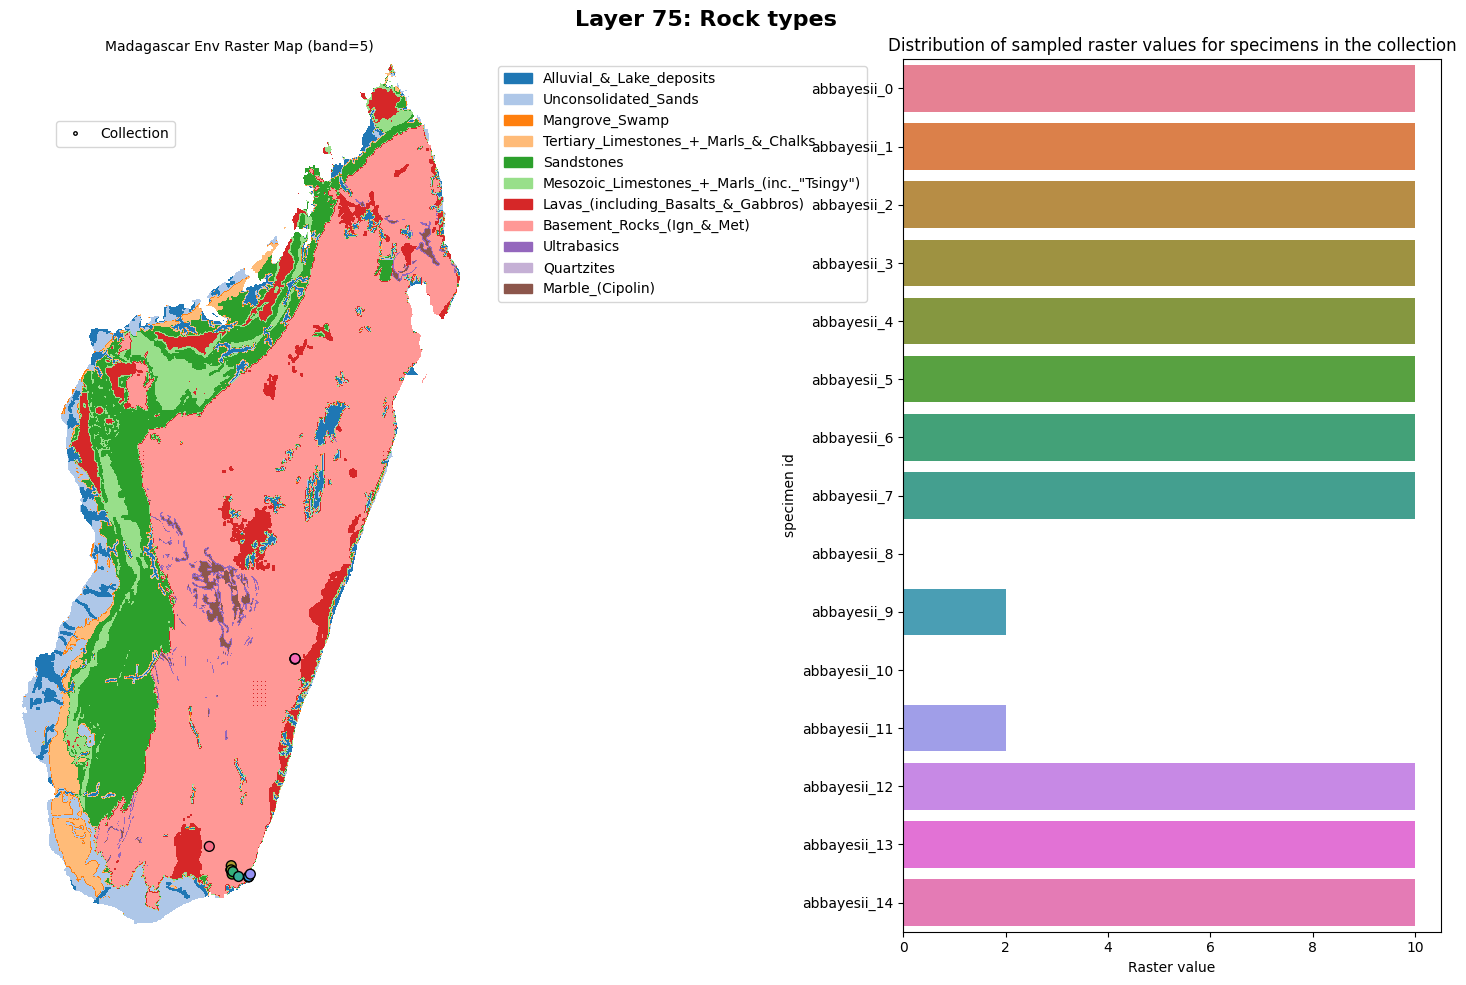

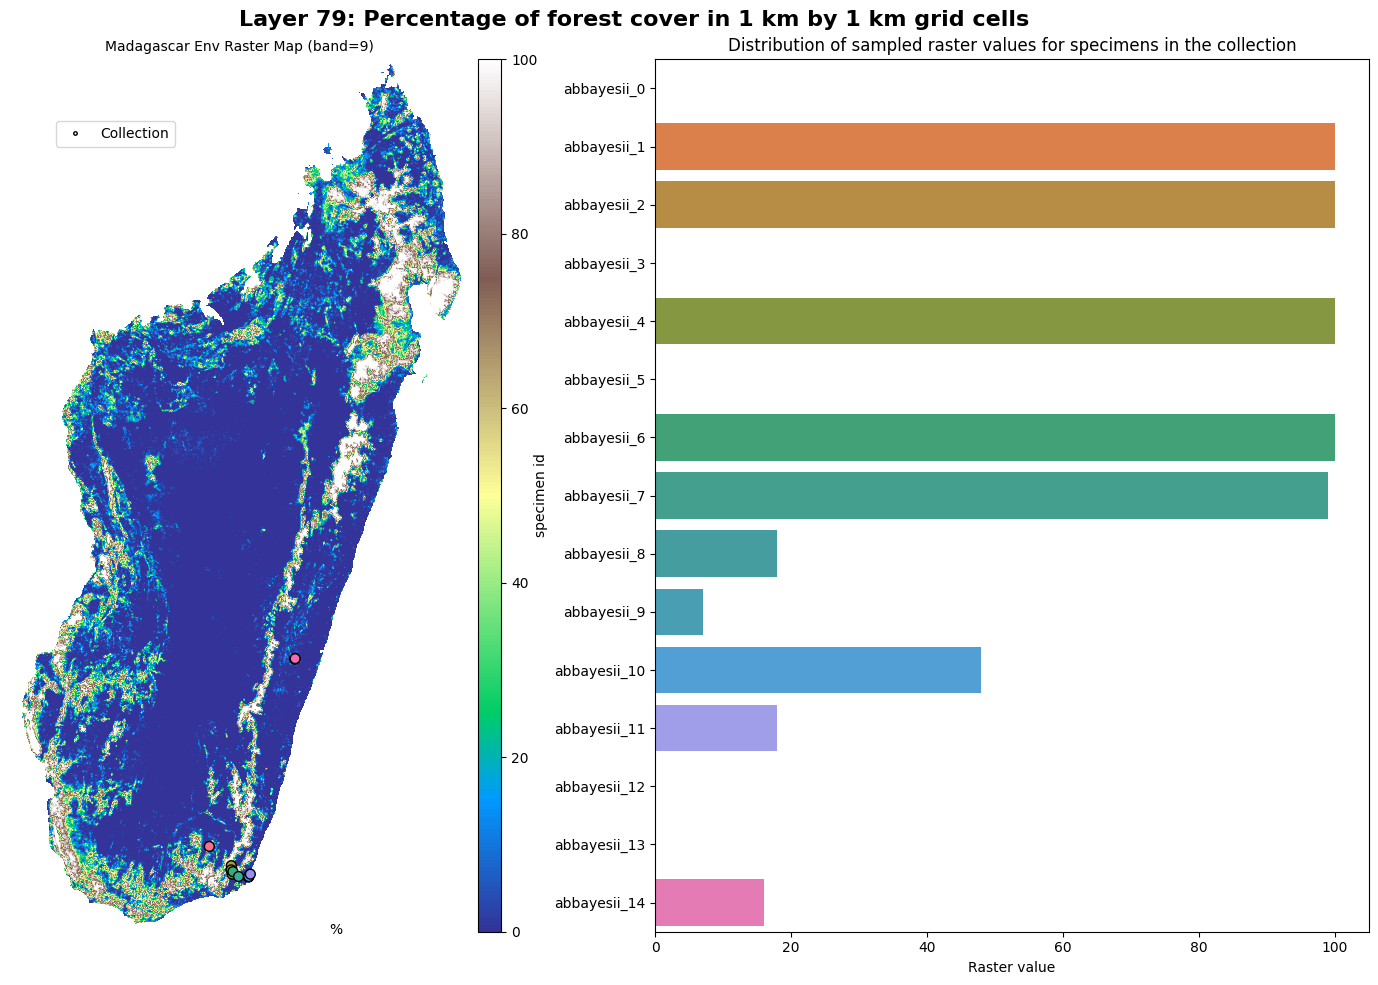

In [84]:
def view_cont_layers(coll, layer_nb):
    coll.plot_on_layer(layer=layer_nb, 
        imshow_cmap="terrain", 
        histplot_binwidth=100, histplot_stat="count", 
        subplots_figsize=(15, 10))

view_cont_layers(coll_abbayesii, "layer_75")

view_cont_layers(coll_abbayesii, "layer_79")

c:\Users\adm1\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


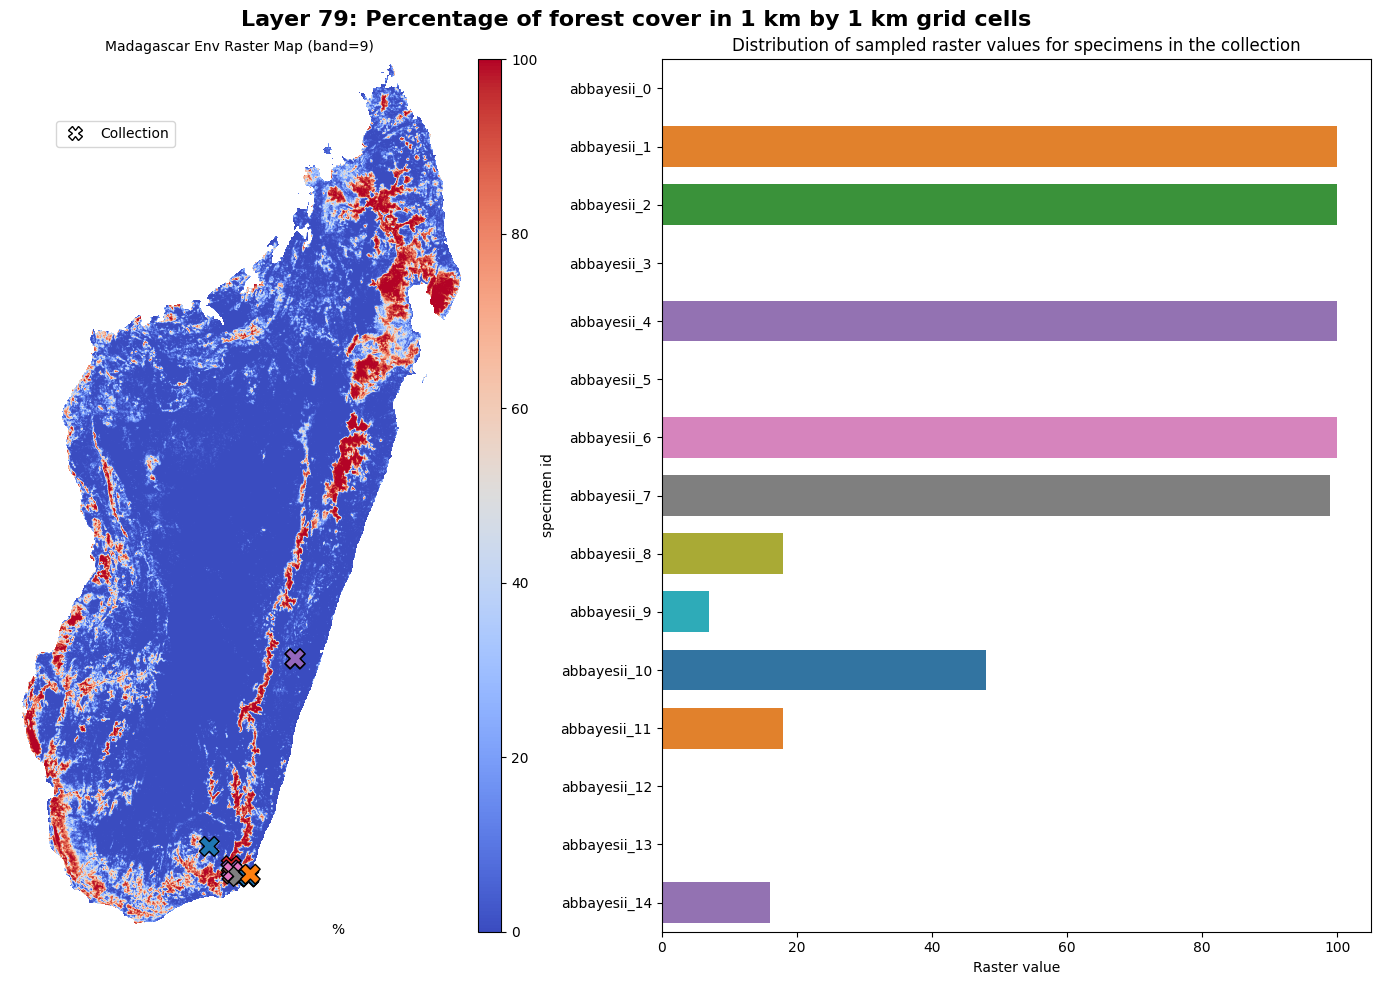

In [85]:
coll_abbayesii.plot_on_layer(
    layer="layer_79",
    subplots_figsize=(15, 10),
    imshow_cmap="coolwarm",
    rasterpoint_marker="X",
    rasterpoint_markersize=200,
    barplot_palette="tab10",    # Use either barplot_palette or rasterpoint_palette
    barplot_width=0.7,
)

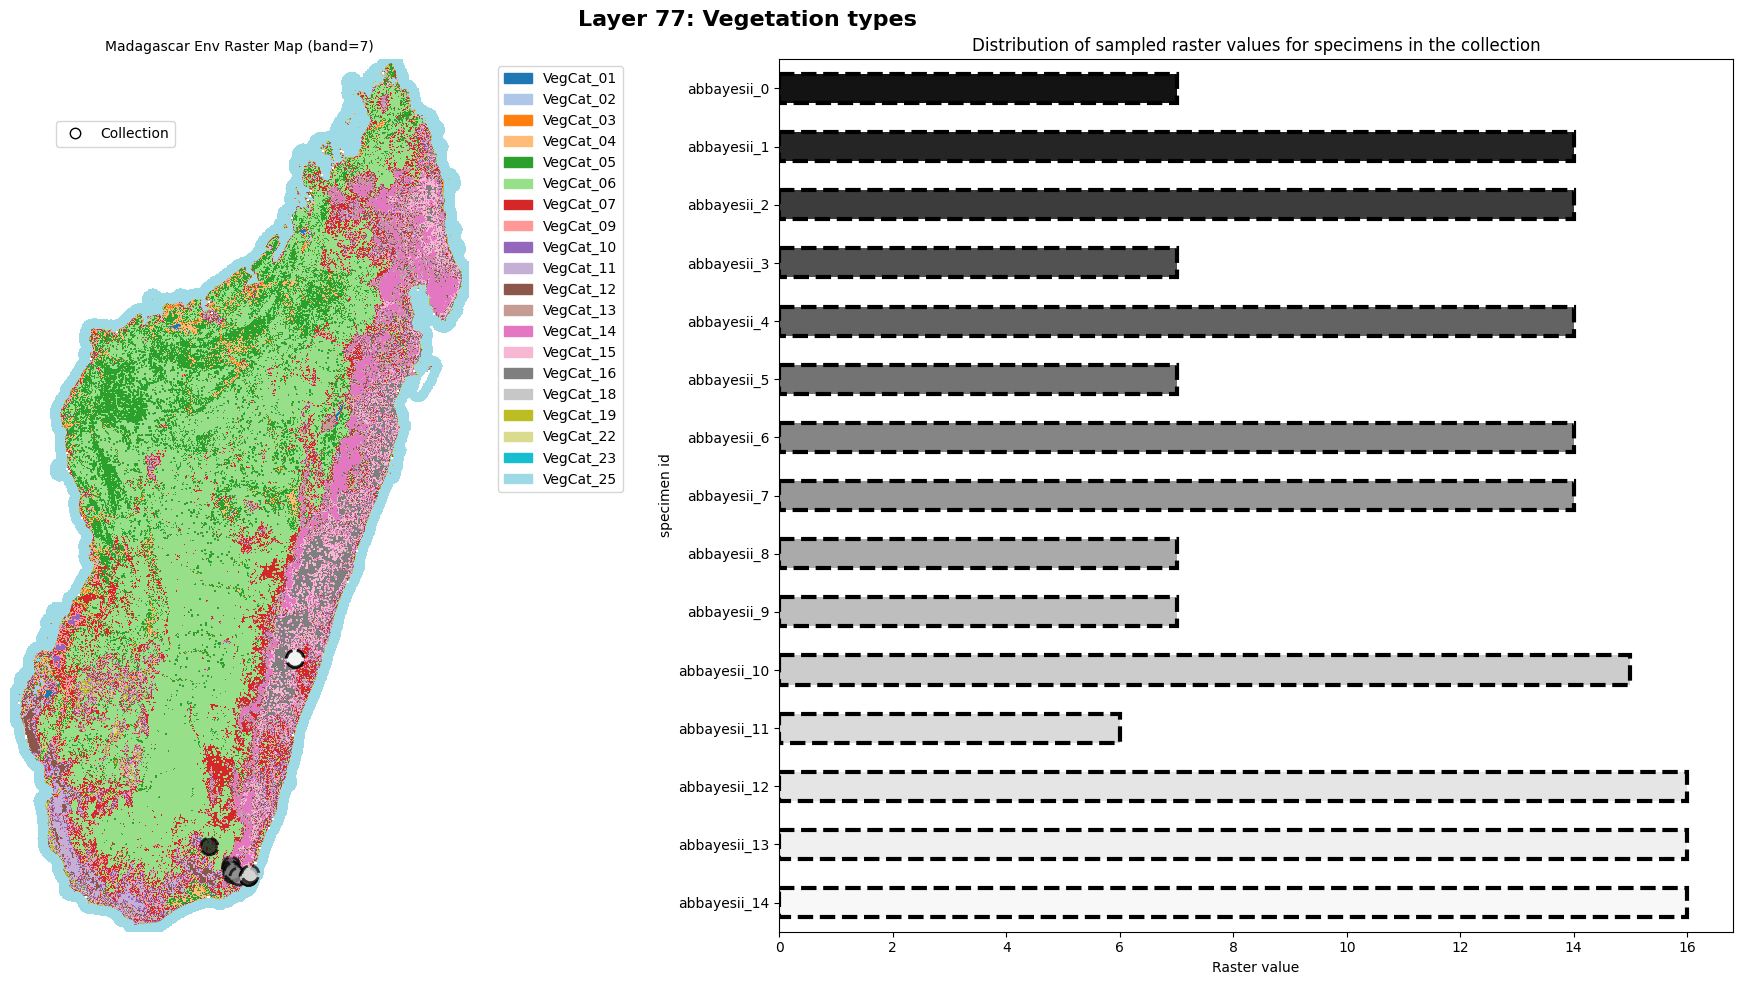

In [86]:
coll_abbayesii.plot_on_layer(
    layer="layer_77",
    rasterpoint_palette="Greys_r",
    rasterpoint_alpha=0.75,
    rasterpoint_markersize=150,
    rasterpoint_linewidths=2,
    rasterpoint_linestyle="--",
    barplot_linewidth=3,
    barplot_edgecolor="black",
    barplot_linestyle="--",
    barplot_width=0.5,
)